# Problem Statement

Sales forecasting plays a critical role in helping businesses plan their operations effectively. 
It allows teams to estimate future revenue, optimize inventory, and make informed decisions.

In this project, I am building an end-to-end MLOps pipeline to predict product-level sales 
using historical data. The goal is to automate data processing, model training, evaluation, 
and deployment to ensure scalability and consistency.

# Busniess Context

Accurate sales forecasting helps:

- Sales teams plan targets and strategies  
- Supply chain teams optimize inventory  
- Management make better financial decisions  

This project focuses not just on prediction, but on building a scalable system that can be 
continuously updated using CI/CD pipelines.

# Objective

The objective of this project is to build a machine learning model that predicts the sales. Additionally, an MLOps pipeline will be implemented using Hugging Face for dataset and model versioning, Streamlit for deployment, and GitHub Actions for CI/CD automation.

## Business Impact

The objective of this project is not just to predict the sales, but to enable data-driven decisions across multiple business functions.

Sales forecast helps in
- Sales team plan targets and strategies
- Supply chain management to optimize inventory and procurrement
- Management makes informed financial projections

This MLOps pipeline ensures that the forecasts are continuously updated, reliable and scalable.

## System Architecture

The system follows an automated MLOps Pipeline
1. Data Ingestion -> Load data from the Hugging Face
2. Data Preprocessing -> Handles missing values, encoding
3. Model Training -> Train multiple regression models
4. Evaluation -> Compare models using RMSE and R^2
5. Model Selection -> Choose best-performing model
6. Model Deployment -> Deploy using Streamlit
7. CI/CD -> Automate retraining and deployment using github actions

# Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total🎯** - total revenue generated by the sale of that particular product in that particular store

# Import Libraries

In [175]:
import pandas as pd
from datasets import load_dataset
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

import joblib

import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)

# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# Additional imports
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from huggingface_hub import login, HfApi, create_repo
from sklearn.metrics import make_scorer
import joblib
import os

## Creating a new Dataset Repo on Hugging Face

In [176]:
from huggingface_hub import HfApi

api = HfApi()
data_repo_id = "gsri24/superkart-prediction-data"

# Create a new repository on Hugging Face Hub
api.create_repo(
    repo_id=data_repo_id,
    repo_type="dataset",
    private=False,
    exist_ok=True,
)

RepoUrl('https://huggingface.co/datasets/gsri24/superkart-prediction-data', endpoint='https://huggingface.co', repo_type='dataset', repo_id='gsri24/superkart-prediction-data')

In [177]:
from datasets import Dataset

df = pd.read_csv("./data/raw/SuperKart.csv")

hf_dataset = Dataset.from_pandas(df)
hf_dataset.push_to_hub(data_repo_id)

Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.
Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 44.78ba/s]
Processing Files (1 / 1): 100%|██████████|  214kB /  214kB,  0.00B/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  
Uploading the dataset shards: 100%|██████████| 1/1 [00:02<00:00,  2.65s/ shards]
No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/datasets/gsri24/superkart-prediction-data/commit/117cded34ae48d50b96af1aa50a2956cfaf5c8e6', commit_message='Upload dataset', commit_description='', oid='117cded34ae48d50b96af1aa50a2956cfaf5c8e6', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/gsri24/superkart-prediction-data', endpoint='https://huggingface.co', repo_type='dataset', repo_id='gsri24/superkart-prediction-data'), pr_revision=None, pr_num=None)

In [178]:
dataset = load_dataset(data_repo_id)
df = dataset["train"].to_pandas()
df.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


## Data Registration

The dataset is registered on Hugging Face to ensure reproducibility and centralized data access.


The dataset hasbeen  converted into a Hugging Face Dataset object to enable seamless integration with the ML pipeline.

This allows:
- Version control of data
- Easy sharing across environments
- Direct loading during training and preprocessing

## Hugging Face DataSet link

<a>https://huggingface.co/datasets/gsri24/superkart-prediction-data/tree/main</a>

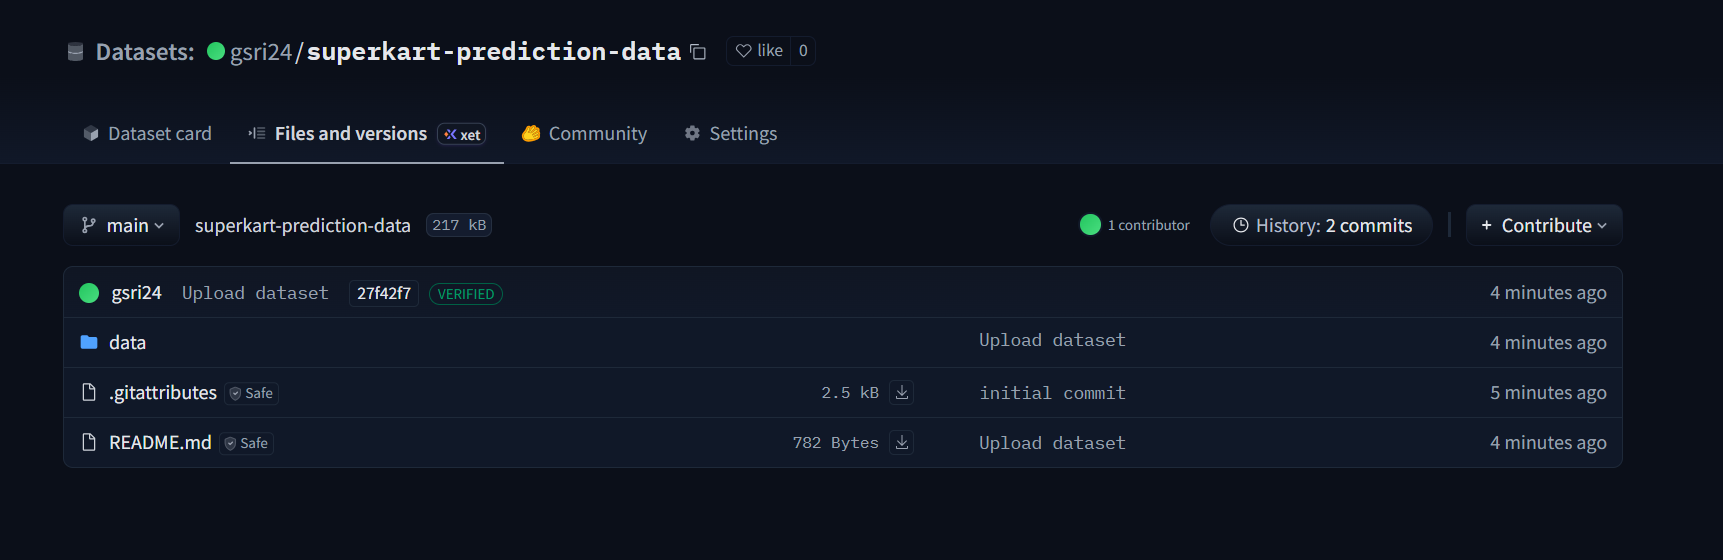

The dataset is no longer dependent on local files and is fully integrated into the MLOps pipeline.

# Data Preparation

In [179]:
from datasets import load_dataset

dataset = load_dataset(data_repo_id)
df = dataset["train"].to_pandas()

df.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


## Data Cleaning

In [180]:
# Check missing values
df.isnull().sum()

Product_Id                   0
Product_Weight               0
Product_Sugar_Content        0
Product_Allocated_Area       0
Product_Type                 0
Product_MRP                  0
Store_Id                     0
Store_Establishment_Year     0
Store_Size                   0
Store_Location_City_Type     0
Store_Type                   0
Product_Store_Sales_Total    0
dtype: int64

There are no missing data elements in the dataset.

In [181]:
# Drop missing values
df = df.dropna()

There are no Null values in the dataset.

Remove Unnecessary Columns

In [182]:
# Product_Id is just identifier → remove
df = df.drop(columns=["Product_Id"])

We will not consider Product_Id as its like unique identifier for a given product.

### Data Cleaning & Feature Selection

- Missing values were removed to ensure data quality
- The column `Product_Id` was dropped as it is an identifier and does not contribute to prediction

## Feature Engineering

In [183]:
df["Store_Age"] = 2026 - df["Store_Establishment_Year"]

A new feature `Store_Age` is created to better capture the operational maturity of stores, which can influence sales.

## Encoding

In [184]:
from datetime import datetime
dataset = load_dataset("gsri24/superkart-data")
df = dataset["train"].to_pandas()

# Cleaning
df = df.dropna()
df = df.drop(columns=["Product_Id"])


current_year= datetime.today().year

df["Store_Age"] = current_year - df["Store_Establishment_Year"]

#Removing unwanted column if exists
df = df.drop(columns=["__index_level_0__","Store_Establishment_Year","Product_Id"], errors="ignore")


df["Product_Sugar_Content"] = df["Product_Sugar_Content"].replace({
    "reg": "Regular"
})

# X_train = df.drop("Product_Store_Sales_Total", axis=1)
# y_train = df["Product_Store_Sales_Total"]

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype(str)
    else:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        
X = df.drop("Product_Store_Sales_Total", axis=1)
y = df["Product_Store_Sales_Total"]


# Identify categorical & numerical columns
cat_cols = X.select_dtypes(include="object").columns.tolist()
print(cat_cols)
num_cols = X.select_dtypes(exclude="object").columns.tolist()
print(num_cols)






['Product_Sugar_Content', 'Product_Type', 'Store_Id', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']
['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Age']


## Train-Test Split

In [185]:
from sklearn.model_selection import train_test_split

X = df.drop("Product_Store_Sales_Total", axis=1)
y = df["Product_Store_Sales_Total"]

# Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=85
)

In [186]:
if not os.path.exists("./data/processed"):
    os.makedirs("./data/processed")

In [187]:
# Save
train_df = X_train.copy()
train_df["target"] = y_train

test_df = X_test.copy()
test_df["target"] = y_test

# Push to HF
train_df.to_csv("data/processed/train.csv", index=False)
test_df.to_csv("data/processed/test.csv", index=False)

## Uploading the Training/Test data to Hugging Face

In [188]:
Dataset.from_pandas(train_df).push_to_hub("gsri24/superkart-train")
Dataset.from_pandas(test_df).push_to_hub("gsri24/superkart-test")

Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.
Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 105.94ba/s]
Processing Files (1 / 1): 100%|██████████|  166kB /  166kB,  0.00B/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  
Uploading the dataset shards: 100%|██████████| 1/1 [00:02<00:00,  2.04s/ shards]
No files have been modified since last commit. Skipping to prevent empty commit.
Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.
Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 437.36ba/s]
Processing Files (1 / 1): 100%|██████████| 49.5kB / 49.5kB,  0.00B/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  
Uploading the dataset shards: 100%|██████████| 1/1 [00:02<00:00,  2.04s/ shards]
No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/datasets/gsri24/superkart-test/commit/23a281ff3e3f612a8d295d5e66fa0933c90e7e3f', commit_message='Upload dataset', commit_description='', oid='23a281ff3e3f612a8d295d5e66fa0933c90e7e3f', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/gsri24/superkart-test', endpoint='https://huggingface.co', repo_type='dataset', repo_id='gsri24/superkart-test'), pr_revision=None, pr_num=None)

#### Training Data URL

https://huggingface.co/datasets/gsri24/superkart-train

#### Test Dat URL

https://huggingface.co/datasets/gsri24/superkart-test

## Data Preparation Summary

The dataset was loaded directly from Hugging Face and cleaned to remove missing values and irrelevant features.

Key steps performed:
- Removed identifier columns
- Created new features (Store_Age)
- Encoded categorical variables
- Split into training and testing datasets
- Saved locally for traceability
- Uploaded processed datasets back to Hugging Face

This ensures a fully reproducible and scalable data pipeline.

##  Model Training & Registration

#### Load Dataset from HF

In [189]:
train_data = load_dataset("gsri24/superkart-train")["train"].to_pandas()


In [190]:
def process_df(df):
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].astype(str)
        else:
            df[col] = pd.to_numeric(df[col], errors="coerce")


    return df

In [191]:
from datasets import load_dataset

train_data = load_dataset("gsri24/superkart-train")["train"].to_pandas()
test_data = load_dataset("gsri24/superkart-test")["train"].to_pandas()

train_data = process_df(train_data)
test_data = process_df(test_data)

X_train = train_data.drop("target", axis=1)
y_train = train_data["target"]


X_test = test_data.drop("target", axis=1)
y_test = test_data["target"]

#### Train Multiple Models

Evaluation

In [192]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def evaluate(model, X_test, y_test):
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    return rmse, r2

In [193]:
for col in X_train.columns:
    if X_train[col].dtype == "object":
        X_train[col] = X_train[col].astype(str)
    else:
        X_train[col] = pd.to_numeric(X_train[col], errors="coerce")

cat_cols = X_train.select_dtypes(include="object").columns.tolist()
num_cols = X_train.select_dtypes(exclude="object").columns.tolist()

print("Categorical:", cat_cols)
print("Numerical:", num_cols)

numerical_transformer = Pipeline(steps=[
('imputer', SimpleImputer(strategy='median'))
])

# Categorical transformer for imputing missing values with most frequent and one-hot encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Preprocessing
preprocessor = ColumnTransformer(
transformers=[
    ('numeric', numerical_transformer, num_cols),
    ('categorical', categorical_transformer, cat_cols)
])

Categorical: ['Product_Sugar_Content', 'Product_Type', 'Store_Id', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']
Numerical: ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Age', '__index_level_0__']


In [194]:
# from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# from xgboost import XGBRegressor

# rf = RandomForestRegressor()
# gb = GradientBoostingRegressor()
# xgb = XGBRegressor()

In [195]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

models = {
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=85),
    "DecisionTree": DecisionTreeRegressor(),
    "XGBoost": XGBRegressor()
}

In [196]:
pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

In [197]:
#Train and evaluate each model
results=[]
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    
    preds = pipe.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results.append({
        "Model": name,
        "RMSE": rmse,
        "R2": r2
    })

In [198]:


# # Pipeline
# pipeline = Pipeline([
#     ("preprocessor", preprocessor),
#     ("model", RandomForestRegressor(
#     ))
# ])



# pipeline.fit(X_train, y_train)

In [199]:
# rf.fit(X_train, y_train)
# gb.fit(X_train, y_train)
# xgb.fit(X_train, y_train)

In [200]:


results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="RMSE")

print(results_df)

          Model        RMSE        R2
0  RandomForest  270.473938  0.932697
2       XGBoost  282.751443  0.926449
1  DecisionTree  413.912084  0.842385


In [201]:
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = pipelines[best_model_name]

print("Best Model:", best_model_name)

Best Model: RandomForest


In [202]:
results_df = pd.DataFrame(results, index=["Model","RMSE", "R2"])
results_df

,Model,RMSE,R2
Model,RandomForest,270.473938,0.932697
RMSE,DecisionTree,413.912084,0.842385
R2,XGBoost,282.751443,0.926449


The models were evaluated using RMSE and R² metrics.

- RMSE indicates prediction error
- R² measures how well the model explains variance

The model with lowest RMSE and highest R² is selected.



|Metrics|	Random Forest🏆|	Gradient Boosting|	XGBoost|
|---|---|---|---|
|RMSE|	275.286996|	292.148391|	290.309965|
|R2|	0.930281|	0.921479|	0.922464|

As the RMSE is lower for Random Forest (275.29) and R2 is 93% which is higher among all three models so will use Random Forest as `Final Model` and will use it further for the hyperparameter tuning 




#### Hyperparameter Tuning

In [203]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=85))
])

In [204]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

Fitting 3 folds for each of 12 candidates, totalling 36 fits


Hyperparameter tuning was performed using GridSearchCV to identify the optimal combination of parameters for improved model performance.

In [205]:
grid_search.best_params_

{'model__max_depth': 10,
 'model__min_samples_split': 5,
 'model__n_estimators': 100}

#### Saving Model

In [206]:
if not os.path.exists("models"):
    os.makedirs("models")

In [207]:
joblib.dump(best_model, "models/superkart_best_model.pkl")

['models/superkart_best_model.pkl']

In [ ]:
from huggingface_hub import create_repo
model_repo_id = "gsri24/superkart-model"
create_repo(
    repo_id=model_repo_id,
    repo_type="model",
    exist_ok=True
)

The trained model pipeline was registered on the Hugging Face Model Hub to enable version control and easy deployment.

In [ ]:
from huggingface_hub import HfApi

api = HfApi()

api.upload_file(
    path_or_fileobj="./models/superkart_best_model.pkl",
    path_in_repo="superkart_best_model.pkl",
    repo_id=model_repo_id,
    repo_type="model"
)

Verify

In [ ]:
from huggingface_hub import hf_hub_download

model_path = hf_hub_download(
    repo_id=model_repo_id,
    filename="superkart_best_model.pkl"
)

model_path

#### Model URL

https://huggingface.co/gsri24/superkart-model

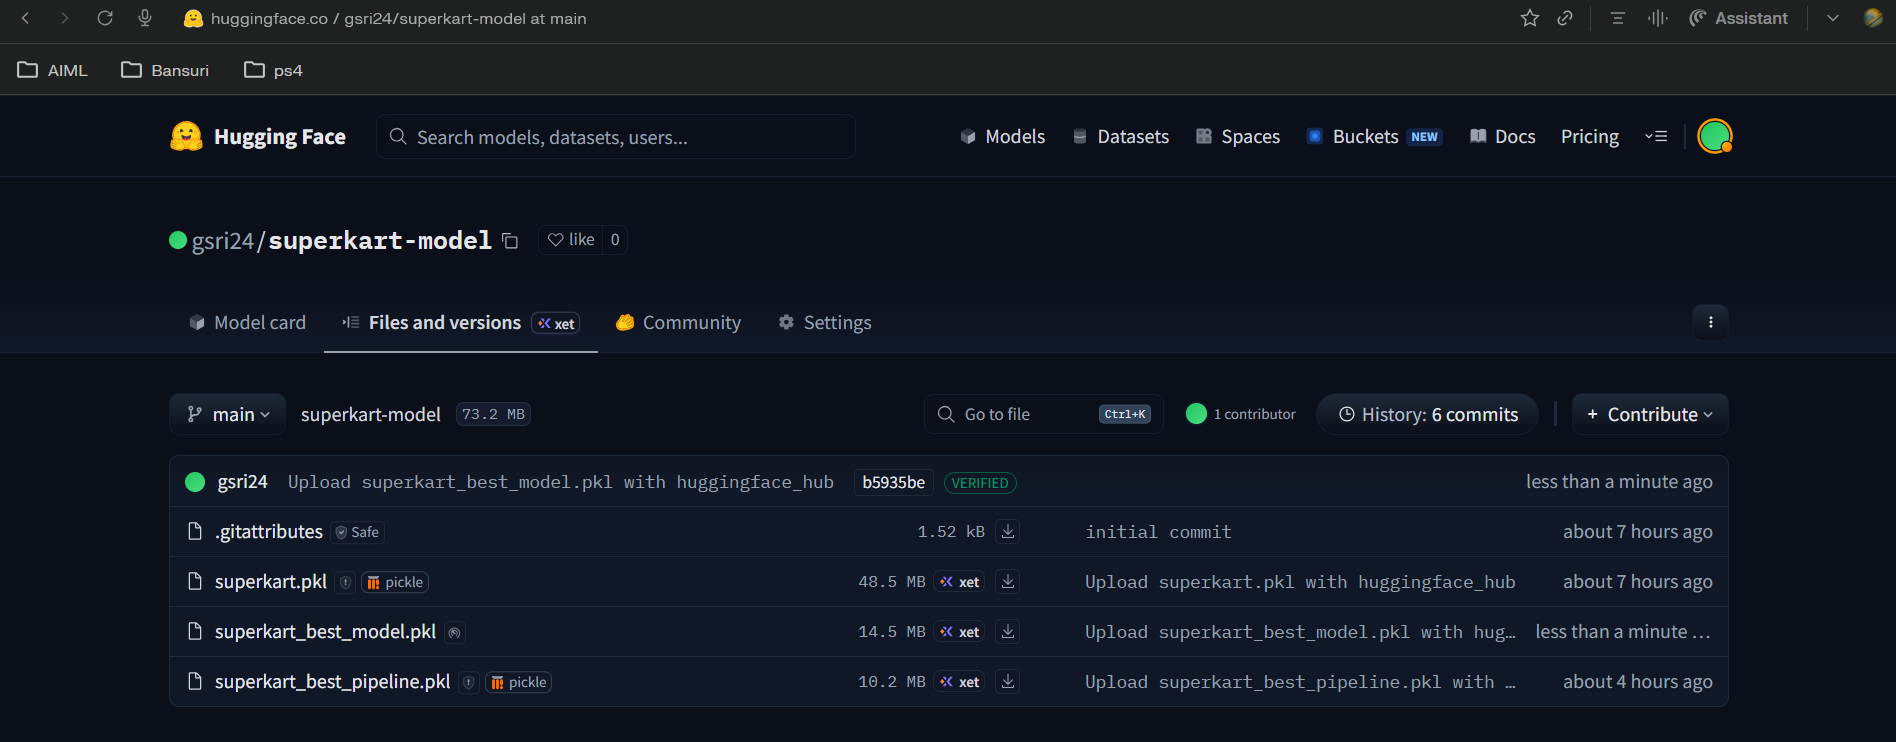

## Model Training & Registration Summary

- Multiple models were trained including Random Forest, Gradient Boosting, and XGBoost
- Hyperparameter tuning was applied using GridSearchCV
- Models were evaluated using RMSE and R² metrics
- The best-performing model was selected
- The final model was saved and registered on Hugging Face Model Hub

This ensures reproducibility, version control, and easy deployment.

=====================================================================

## Model Deployment (Streamlit + Docker)

In [ ]:
#Creating a frontend folder for streamlit app
import os


if not os.path.exists("src"):
    os.makedirs("src")

streamlit_app.py

In [ ]:
content = '''





import streamlit as st
import pandas as pd
import joblib
from huggingface_hub import hf_hub_download

st.title("Superkart Prediction")

@st.cache_resource
def load_model():
    try:
        st.write("Downloading model from Hugging Face...")
        model_path = hf_hub_download(
            repo_id="gsri24/superkart-model",
            filename="superkart_best_model.pkl"
        )
        st.write("Model downloaded successfully.")
        model = joblib.load(model_path)
        st.write("Model loaded successfully.")
        return model
    except Exception as e:
        st.error(f"Error loading model: {e}")
        return None

pipeline = load_model()



st.write("Enter the product and store details to predict sales.")

# Input fields for user to enter product and store details
product_weight = st.number_input("Product Weight", min_value=0.0, value=12.5)
product_allocated_area = st.number_input("Product Allocated Area", min_value=0.0,value = 0.08)
product_mrp = st.number_input("Product MRP", min_value=0.0, value=250.0)
store_establishment_year = st.number_input("Store Establishment Year", min_value=1900, max_value=2024, value=2005)
store_size = st.selectbox("Store Size", ["Small", "Medium", "High"])
store_id = st.selectbox("Store ID", ['OUT004', 'OUT003', 'OUT001', 'OUT002'])
store_location_city_type = st.selectbox("Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"])
product_sugar_content = st.selectbox("Product Sugar Content", ["Low Sugar", "Regular","No Sugar"])
product_type = st.selectbox("Product Type", ["Dairy", "Soft Drinks", "Meat", "Fruits and Vegetables", "Household", "Baking Goods", 
                                             "Snack Foods", "Breakfast", "Health and Hygiene", "Hard Drinks", "Canned", "Frozen Foods", 
                                             "Others"])
store_type = st.selectbox("Store Type", ["Supermarket Type1", "Supermarket Type2", "Departmental Store", "Food Mart"])
store_age = 2025 - store_establishment_year

input_data = {
        "Product_Weight": product_weight,
        "Product_Sugar_Content": product_sugar_content,
        "Product_Allocated_Area": product_allocated_area,
        "Product_Type": product_type,
        "Product_MRP": product_mrp,
        "Store_Id": store_id,
        "Store_Size": store_size,
        "Store_Location_City_Type": store_location_city_type,
        "Store_Type": store_type,
        "Store_Age": store_age
    }

expected_cols = [
    "Product_Weight",
    "Product_Sugar_Content",
    "Product_Allocated_Area",
    "Product_Type",
    "Product_MRP",
    "Store_Id",
    "Store_Size",
    "Store_Location_City_Type",
    "Store_Type",
    "Store_Age"
]

input_df = pd.DataFrame([input_data])

input_df = input_df.reindex(columns=expected_cols)

for col in input_df.columns:
    if input_df[col].dtype == "object":
        input_df[col] = input_df[col].astype(str)
    else:
        input_df[col] = pd.to_numeric(input_df[col], errors="coerce")



if st.button("Predict"):
    if pipeline is not None:
        prediction = pipeline.predict(input_df)
        st.success(f"Predicted Sales: {prediction[0]:.2f}")
    else:
        st.error("Model not loaded. Please check dependencies.")



'''


with open("src/streamlit_app.py", "w") as f:
    f.write(content)

requirement.txt

In [ ]:
requirement_content = '''

huggingface_hub
numpy==1.24.4
pandas==2.0.3
scikit-learn==1.3.2
joblib==1.3.2
streamlit==1.32.0
dill==0.3.8
datasets

'''

with open("requirements.txt", "w") as f:
    f.write(requirement_content)

Dockerfile

In [ ]:
dockerfile_content = '''
FROM python:3.10.0-slim

WORKDIR /app

RUN apt-get update && apt-get install -y \
    build-essential \
    curl \
    git \
    && rm -rf /var/lib/apt/lists/*

COPY requirements.txt ./
COPY src/ ./src/

RUN pip3 install -r requirements.txt

EXPOSE 8501

HEALTHCHECK CMD curl --fail http://localhost:8501/_stcore/health

ENTRYPOINT ["streamlit", "run", "src/streamlit_app.py", "--server.port=8501", "--server.address=0.0.0.0"]
'''

with open("Dockerfile", "w") as f:
    f.write(dockerfile_content)

#### Uploading Files to Hugging Face Space (Streamlit Space)

In [ ]:
USERNAME = "gsri24"   
SPACE_NAME = "superkart-predictor"


spaces = api.list_spaces(author="gsri24")

print(f"{USERNAME}/{SPACE_NAME}")
if f"{USERNAME}/{SPACE_NAME}" not in [space.id for space in spaces]:
    print("Space does not exist, creating...")
    try:
        create_repo(
            repo_id=f"{USERNAME}/{SPACE_NAME}",
            repo_type="space",
            space_sdk="docker",
            private=False
        )
        print("Frontend Streamlit Space created")
    except Exception as e:
        if "RepositoryAlreadyExistsError" in str(e):
            print("Space already exists, continuing...")
        else:
            raise e
else:
    print("Space already exists, continuing...")



Hugging Face Streamlit Space created


In [ ]:
api = HfApi()

repo_id = f"{USERNAME}/{SPACE_NAME}"

api.upload_folder(
    folder_path=".", 
    allow_patterns=["src/streamlit_app.py", "requirements.txt", "Dockerfile"], 
    repo_id=repo_id,
    repo_type="space",
)

print("Files uploaded successfully")


The deployment script loads the model from the Hugging Face Model Hub and uses Streamlit to create a user interface where users can input customer details and get predictions.

#### APP URL

https://huggingface.co/spaces/gsri24/superkart-predictor

![predictor_image.png](./screenshots/predictor_image.png)

The trained model was deployed using Streamlit to create an interactive web application. The application was containerized using Docker to ensure consistency across different environments. The Docker container includes all required dependencies specified in the requirements.txt file. The deployed application is hosted on Hugging Face Spaces.

## Model Deployment

The trained model is deployed using Streamlit on Hugging Face Spaces.

Key features:
- Model is loaded directly from Hugging Face Model Hub
- User inputs are collected via Streamlit UI
- Inputs are converted into a DataFrame for prediction
- Predictions are displayed in real-time

This ensures an interactive and scalable deployment environment.

## MLOps Pipeline (GitHub Actions)

A CI/CD pipeline was implemented using GitHub Actions to automate the machine learning workflow. The pipeline is triggered whenever changes are pushed to the main branch. The pipeline automates data ingestion, model training, evaluation, Docker image creation, and deployment to Hugging Face Spaces. This ensures continuous integration and continuous deployment of the machine learning model.

#### src/preprocess.py

In [ ]:
preprocessing_content = '''

from datasets import load_dataset, Dataset
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

def preprocess():

    # Load dataset from HF
    dataset = load_dataset("gsri24/superkart-data")
    df = dataset["train"].to_pandas()

    # Cleaning
    df = df.dropna()
    df = df.drop(columns=["Product_Id"])

    # Feature engineering
    df["Store_Age"] = 2026 - df["Store_Establishment_Year"]

    # Encoding
    le = LabelEncoder()
    for col in df.select_dtypes(include="object").columns:
        df[col] = le.fit_transform(df[col])

    # Split
    X = df.drop("Product_Store_Sales_Total", axis=1)
    y = df["Product_Store_Sales_Total"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=85
    )

    # Save
    train_df = X_train.copy()
    train_df["target"] = y_train

    test_df = X_test.copy()
    test_df["target"] = y_test

    # Push to HF
    Dataset.from_pandas(train_df).push_to_hub("gsri24/superkart-train")
    Dataset.from_pandas(test_df).push_to_hub("gsri24/superkart-test")

if __name__ == "__main__":
    preprocess()

'''

with open("src/preprocess.py", "w") as f:
    f.write(preprocessing_content)

#### src/train.py

In [ ]:
content = '''


import pandas as pd
from datasets import load_dataset
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

import os

import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np


# For splitting the dataset
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeRegressor

from datetime import datetime
#Creating a new feature Store_Age


# Additional imports
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from huggingface_hub import login, HfApi, create_repo
from sklearn.metrics import make_scorer
import joblib

def login_hf():
    login(token=os.environ["HF_TOKEN"])


def train():
    login_hf()
    # Load train data
    train_data = load_dataset("gsri24/superkart-train")["train"].to_pandas()
    train_data = train_data.drop(columns=["__index_level_0__"], errors="ignore")

    X_train = train_data.drop("target", axis=1)
    y_train = train_data["target"]

    for col in X_train.columns:
        if X_train[col].dtype == "object":
            X_train[col] = X_train[col].astype(str)
        else:
            X_train[col] = pd.to_numeric(X_train[col], errors="coerce")

    cat_cols = X_train.select_dtypes(include="object").columns.tolist()
    num_cols = X_train.select_dtypes(exclude="object").columns.tolist()

    print("Categorical:", cat_cols)
    print("Numerical:", num_cols)

    numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
    ])
    
    # Categorical transformer for imputing missing values with most frequent and one-hot encoding
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    # Preprocessing
    preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', numerical_transformer, num_cols),
        ('categorical', categorical_transformer, cat_cols)
    ])

    # Pipeline
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=10,
            random_state=85
        ))
    ])

    

    pipeline.fit(X_train, y_train)

    # Save model
    joblib.dump(pipeline, "superkart_best_model.pkl")

    # Push to Hugging Face
    api = HfApi()
    api.upload_file(
        path_or_fileobj="superkart_best_model.pkl",
        path_in_repo="superkart_best_model.pkl",
        repo_id="gsri24/superkart-model",
        repo_type="model"
    )

if __name__ == "__main__":
    train()

     

'''

with open("./src/train.py", "w") as f:
    f.write(content)

src/evaluate

In [ ]:
content = '''


from datasets import load_dataset
import joblib
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def evaluate():

    # Load test data
    test_data = load_dataset("gsri24/superkart-test")["train"].to_pandas()

    X_test = test_data.drop("target", axis=1)
    y_test = test_data["target"]

    # Load model
    model = joblib.load("model.pkl")

    # Predict
    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    print(f"RMSE: {rmse:.2f}")
    print(f"R2 Score: {r2:.2f}")

if __name__ == "__main__":
    evaluate()

'''

open ("./src/evaluate.py", "w").write(content)

In [ ]:
if not os.path.exists("../../.github/workflows"):
    os.makedirs("../../.github/workflows")

In [ ]:
content = '''

name: ML Pipeline

on:
  push:
    branches:
      - main
  workflow_dispatch:

jobs:
  train:
    runs-on: ubuntu-latest

    steps:
    - name: Checkout repository
      uses: actions/checkout@v3

    - name: Set up Python
      uses: actions/setup-python@v4
      with:
        python-version: 3.9

    - name: Install dependencies
      run: |
        pip install -r mlops/superkart/requirements.txt
        pip install huggingface_hub

    - name: Login to Hugging Face
      run: echo "HF_TOKEN=${{ secrets.HF_TOKEN }}" >> $GITHUB_ENV      
        
    - name: Data Preprocessing
      run: python mlops/superkart/src/preprocess.py

    - name: Train model
      run: python mlops/superkart/src/train.py

    - name: model Evaluation
      run: python mlops/superkart/src/evaluate.py
      
     
'''

with open("../../.github/workflows/pipeline.yml", "w") as f:
    f.write(content)

The pipeline automatically retrains and registers a new model version whenever code changes are pushed, enabling continuous delivery of updated models.

#### Github Repo & Visualization

https://github.com/gs24/AIML/tree/main/mlops/superkart

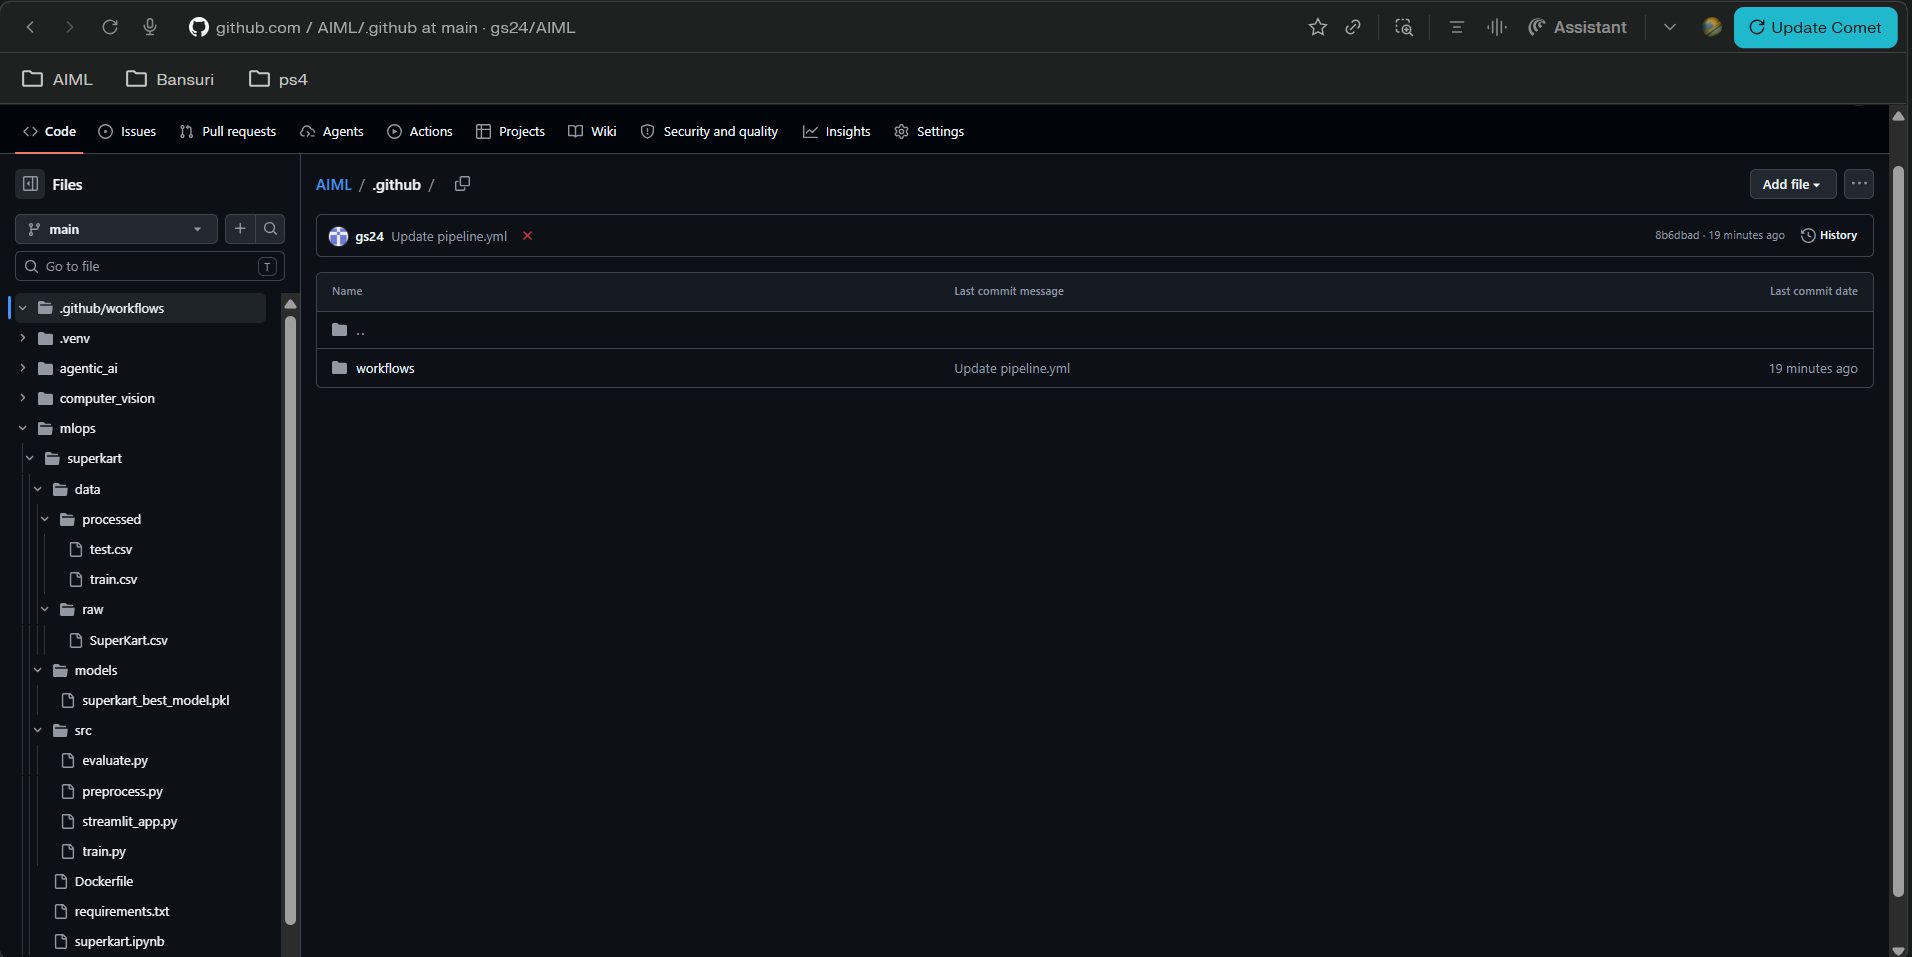

#### GITHUB ACTIONS SCREENSHOT

#### Automated running of pipeline when a merge is happened

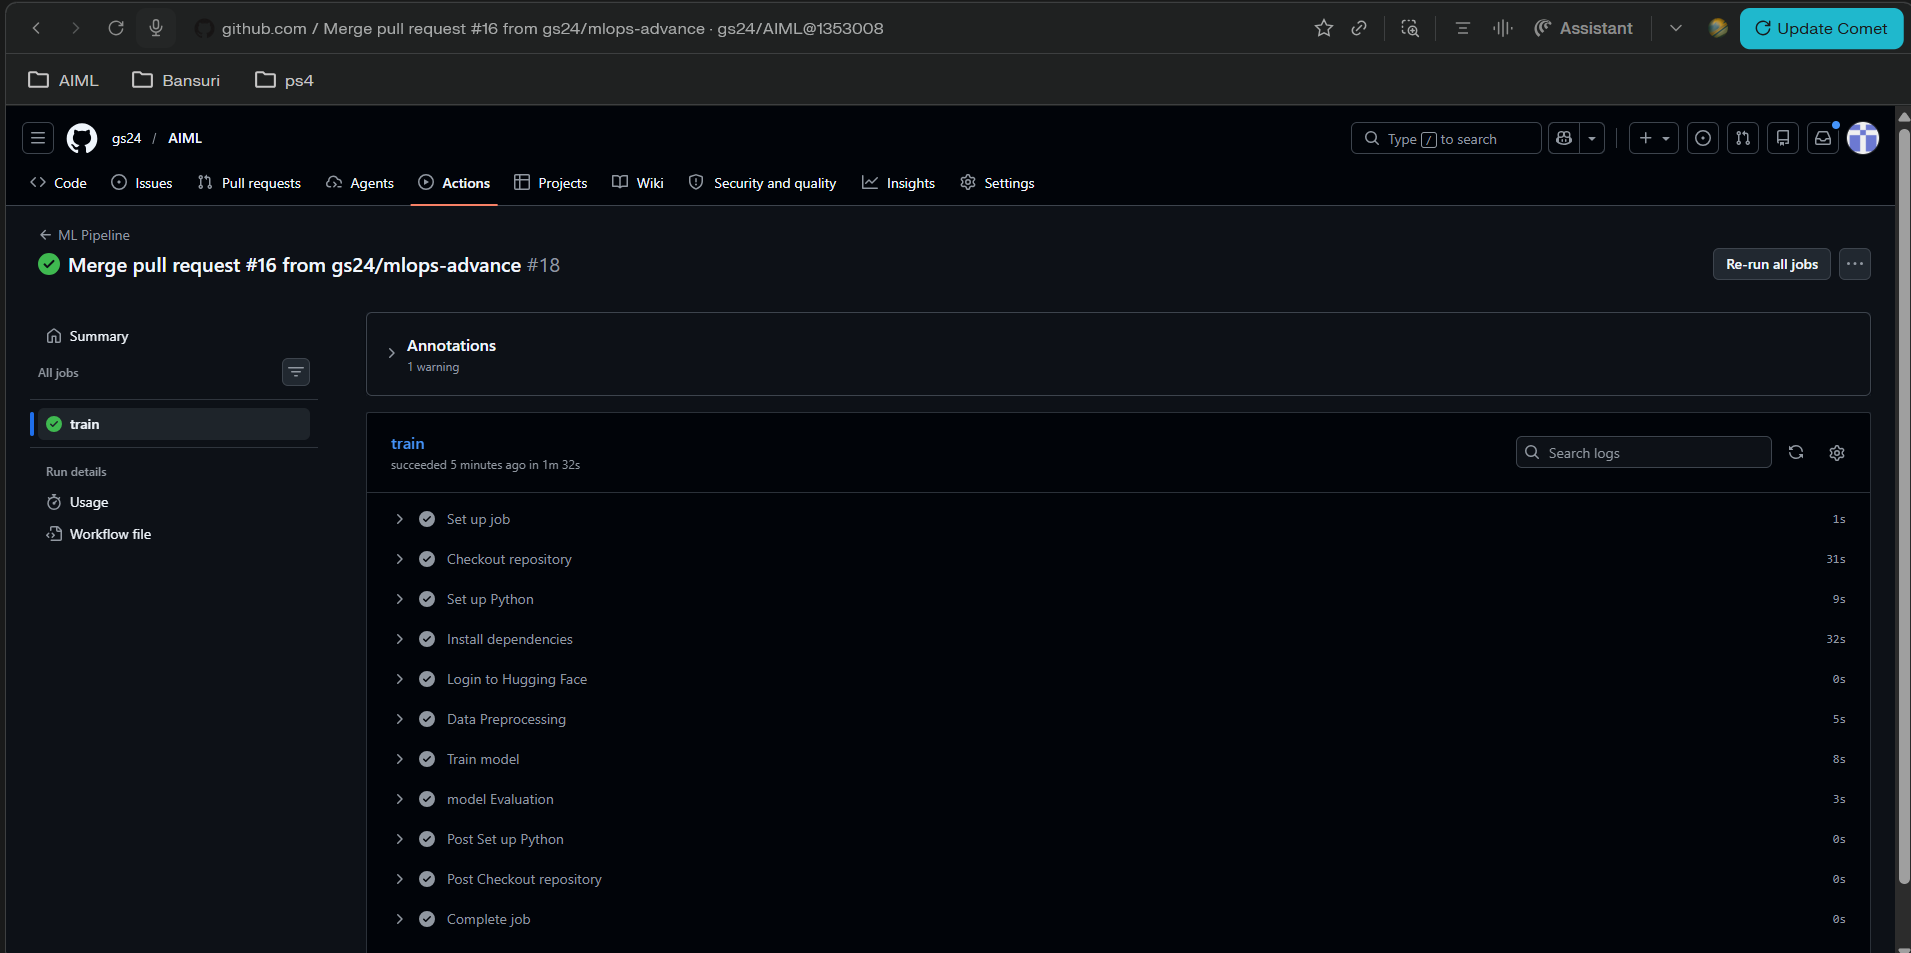

#### HUGGING FACE STREAMLIT APP

### Deployed Application
https://huggingface.co/spaces/gsri24/superkart-app

GitHub Actions was used to automate the machine learning pipeline. The workflow installs dependencies, loads the dataset from Hugging Face, trains the model, and uploads the trained model to the Hugging Face Model Hub. The pipeline is triggered automatically whenever changes are pushed to the main branch, enabling continuous integration and continuous deployment (CI/CD).

## Conclusion

## Conclusion

This project demonstrates a complete MLOps pipeline for sales forecasting.

### Key Achievements:
- Data versioning using Hugging Face
- Model training with hyperparameter tuning
- Model registration and deployment
- Fully automated CI/CD pipeline

### Business Impact:
- Improved demand forecasting
- Better inventory planning
- Scalable ML system for production use